Purpose: understand dataset shape, time coverage, per-company history length, missingness, and split integrity.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

DATA_PATH = "../data/interim/balance_sheet_model_with_ratios.parquet"
TRAIN_PATH = "../data/interim/train.parquet"
VAL_PATH = "../data/interim/val.parquet"
TEST_PATH = "../data/interim/test.parquet"  

In [8]:
df = pd.read_parquet(DATA_PATH)

print("Shape:", df.shape)
df.head()


Shape: (72575, 113)


,cik,end,Assets,AssetsCurrent,AssetsNoncurrent,Liabilities,LiabilitiesCurrent,LiabilitiesNoncurrent,StockholdersEquity,LiabilitiesAndStockholdersEquity,CashAndCashEquivalentsAtCarryingValue,CashCashEquivalentsRestrictedCashAndRestrictedCashEquivalents,AccountsReceivableNetCurrent,InventoryNet,PrepaidExpenseCurrent,PropertyPlantAndEquipmentNet,Goodwill,IntangibleAssetsNetExcludingGoodwill,DebtCurrent,LongTermDebt,LongTermDebtCurrent,AccountsPayableCurrent,AccruedLiabilitiesCurrent,RetainedEarningsAccumulatedDeficit,CommonStockValue,AdditionalPaidInCapital,AccumulatedOtherComprehensiveIncomeLossNetOfTax,Assets_lag1,AssetsCurrent_lag1,AssetsNoncurrent_lag1,Liabilities_lag1,LiabilitiesCurrent_lag1,LiabilitiesNoncurrent_lag1,StockholdersEquity_lag1,LiabilitiesAndStockholdersEquity_lag1,CashAndCashEquivalentsAtCarryingValue_lag1,CashCashEquivalentsRestrictedCashAndRestrictedCashEquivalents_lag1,AccountsReceivableNetCurrent_lag1,InventoryNet_lag1,PrepaidExpenseCurrent_lag1,PropertyPlantAndEquipmentNet_lag1,Goodwill_lag1,IntangibleAssetsNetExcludingGoodwill_lag1,DebtCurrent_lag1,LongTermDebt_lag1,LongTermDebtCurrent_lag1,AccountsPayableCurrent_lag1,AccruedLiabilitiesCurrent_lag1,RetainedEarningsAccumulatedDeficit_lag1,CommonStockValue_lag1,AdditionalPaidInCapital_lag1,AccumulatedOtherComprehensiveIncomeLossNetOfTax_lag1,y_Assets,y_Assets_is_log,y_AssetsCurrent,y_AssetsCurrent_is_log,y_AssetsNoncurrent,y_AssetsNoncurrent_is_log,y_Liabilities,y_Liabilities_is_log,y_LiabilitiesCurrent,y_LiabilitiesCurrent_is_log,y_LiabilitiesNoncurrent,y_LiabilitiesNoncurrent_is_log,y_StockholdersEquity,y_StockholdersEquity_is_log,y_LiabilitiesAndStockholdersEquity,y_LiabilitiesAndStockholdersEquity_is_log,y_CashAndCashEquivalentsAtCarryingValue,y_CashAndCashEquivalentsAtCarryingValue_is_log,y_CashCashEquivalentsRestrictedCashAndRestrictedCashEquivalents,y_CashCashEquivalentsRestrictedCashAndRestrictedCashEquivalents_is_log,y_AccountsReceivableNetCurrent,y_AccountsReceivableNetCurrent_is_log,y_InventoryNet,y_InventoryNet_is_log,y_PrepaidExpenseCurrent,y_PrepaidExpenseCurrent_is_log,y_PropertyPlantAndEquipmentNet,y_PropertyPlantAndEquipmentNet_is_log,y_Goodwill,y_Goodwill_is_log,y_IntangibleAssetsNetExcludingGoodwill,y_IntangibleAssetsNetExcludingGoodwill_is_log,y_DebtCurrent,y_DebtCurrent_is_log,y_LongTermDebt,y_LongTermDebt_is_log,y_LongTermDebtCurrent,y_LongTermDebtCurrent_is_log,y_AccountsPayableCurrent,y_AccountsPayableCurrent_is_log,y_AccruedLiabilitiesCurrent,y_AccruedLiabilitiesCurrent_is_log,y_RetainedEarningsAccumulatedDeficit,y_RetainedEarningsAccumulatedDeficit_is_log,y_CommonStockValue,y_CommonStockValue_is_log,y_AdditionalPaidInCapital,y_AdditionalPaidInCapital_is_log,y_AccumulatedOtherComprehensiveIncomeLossNetOfTax,y_AccumulatedOtherComprehensiveIncomeLossNetOfTax_is_log,cash_to_assets,current_assets_to_assets,liab_to_assets,equity_to_assets,current_liab_to_liab,ppe_to_assets,goodwill_to_assets,intangibles_to_assets,wc_to_assets,debt_to_assets,debt_to_equity
0,0000001750,2025-02-28,"2,859,100,000.0000","1,534,800,000.0000",NaN,NaN,"545,200,000.0000","1,131,300,000.0000",NaN,"2,859,100,000.0000","84,400,000.0000","100,900,000.0000",NaN,"775,700,000.0000",NaN,"153,400,000.0000","528,400,000.0000","223,600,000.0000",NaN,NaN,NaN,"278,900,000.0000","236,700,000.0000","935,400,000.0000","45,300,000.0000",NaN,"-12,100,000.0000","2,849,300,000.0000","1,498,000,000.0000",NaN,NaN,"558,300,000.0000","1,109,400,000.0000",NaN,"2,849,300,000.0000","61,700,000.0000","82,500,000.0000",NaN,"790,000,000.0000",NaN,"167,000,000.0000","543,200,000.0000","227,300,000.0000",NaN,NaN,NaN,"291,800,000.0000","258,800,000.0000","944,300,000.0000","45,300,000.0000",NaN,"-10,600,000.0000",0.0034,1,0.0243,1,NaN,0,NaN,0,-0.0237,1,0.0195,1,NaN,0,0.0034,1,0.3133,1,0.2013,1,NaN,0,-0.0183,1,NaN,0,-0.0849,1,-0.0276,1,-0.0164,1,NaN,0,NaN,0,NaN,0,-0.0452,1,-0.0893,1,-0.0095,1,0.0000,1,NaN,0,-3.0000,0,0.0295,0.5368,NaN,NaN,NaN,0.0537,0.1848,0.0782,0.3461,0.0000,NaN
1,0000001750,

What we checked: dataset loads correctly, shape, and column structure.

What we found: dataset has 72,575 rows × 113 columns, with expected fields (cik, end, raw balance-sheet items, _lag1, y_*, ratio features).

Why it matters: confirms the modeling table is complete and aligns with the pipeline splits; also reveals real-world SEC sparsity (many NaNs in raw fields).

Next action: inspect datatypes + memory (df.info) and then quantify missingness.

In [9]:
df.dtypes.value_counts()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72575 entries, 0 to 72574
Columns: 113 entries, cik to debt_to_equity
dtypes: datetime64[ns](1), float64(86), int8(25), object(1)
memory usage: 50.5+ MB


What we checked: column data types and memory footprint of the modeling dataset.

What we found: 113 columns consisting of 86 float64, 25 int8 flags, 1 datetime, and 1 object (cik), for a total memory usage of ~50.5 MB.

Why it matters: confirms efficient storage (binary *_is_log flags as int8) and that the dataset is large but manageable for tree-based models and local experimentation.

Next action: analyze missing-value patterns and sparsity across raw balance-sheet items, lag features, and ratios.

In [10]:
required_cols = ["cik", "end", "y_Assets"]
missing_required = [c for c in required_cols if c not in df.columns]
missing_required
# Parse date
df["end"] = pd.to_datetime(df["end"], errors="coerce")

print("Null cik:", df["cik"].isna().sum())
print("Null end:", df["end"].isna().sum())
print("Null y_Assets:", df["y_Assets"].isna().sum())
# Duplicate checks
dup = df.duplicated(subset=["cik", "end"]).sum()
print("Duplicated (cik, end):", dup)


Null cik: 0
Null end: 0
Null y_Assets: 0
Duplicated (cik, end): 0


What we checked: completeness and uniqueness of core identifiers (cik, end) and the target variable (y_Assets).

What we found:

No missing values in cik, end, or y_Assets.

No duplicate (cik, end) combinations.

Why it matters: confirms that the modeling dataset is fully aligned, time-indexed per company, and safe for panel-based time-series learning without leakage or ambiguity.

Implication for modeling: downstream splits, lag features, and evaluation metrics rely on a clean and deterministic company–date structure, which is satisfied here.

Next action: analyze missingness and sparsity in non-core financial variables (raw balance-sheet items, lagged values, and ratios).

Min date: 2001-12-31 00:00:00
Max date: 2025-11-01 00:00:00
Unique dates: 1314


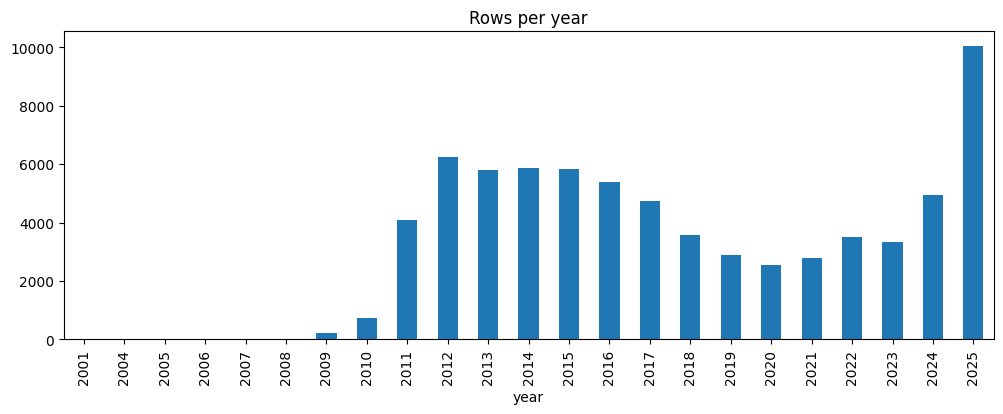

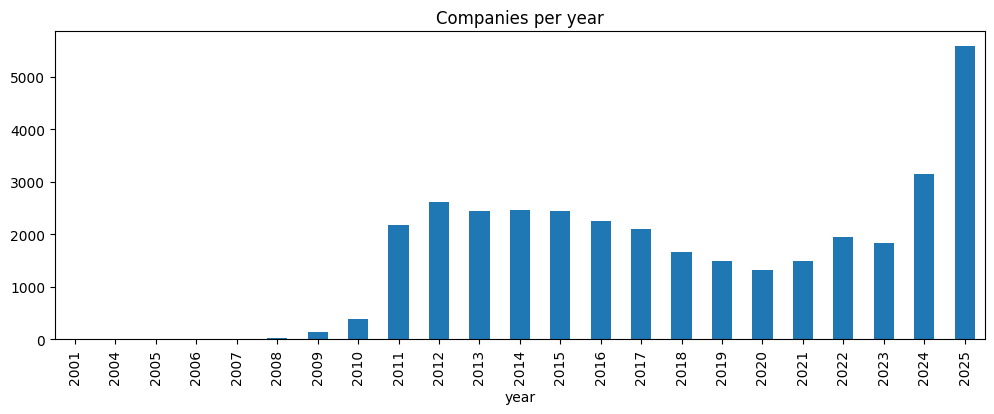

In [11]:
print("Min date:", df["end"].min())
print("Max date:", df["end"].max())
print("Unique dates:", df["end"].nunique())
df["year"] = df["end"].dt.year

rows_by_year = df.groupby("year").size()
companies_by_year = df.groupby("year")["cik"].nunique()
rows_by_year.plot(kind="bar", figsize=(12,4), title="Rows per year")
plt.show()

companies_by_year.plot(kind="bar", figsize=(12,4), title="Companies per year")
plt.show()


What we analyzed: temporal distribution of observations and company coverage over time.

Time span: data ranges from 2001 to late 2025, with 1,314 unique reporting dates.

Rows per year:

Very sparse coverage before ~2009.

Rapid expansion between 2010–2015, peaking around 2012–2015.

Noticeable dip around 2018–2021, followed by a strong rebound in 2024–2025.

Companies per year:

Follows a similar pattern to row counts, confirming that variation is driven by coverage, not duplicated filings.

Peak company coverage occurs in 2025, likely due to more recent filings and improved data availability.

Why it matters:

The dataset is unbalanced over time, which is typical for SEC-based panel data.

Models must rely on within-company temporal structure (lags, ratios) rather than uniform cross-sectional snapshots.

Implication for modeling:

Validates the choice of company-wise splits and lag-based features.

Encourages caution when interpreting long-horizon temporal trends (early years are underrepresented).

Next action: analyze observations per company to quantify panel depth and identify firms with short vs long histories.

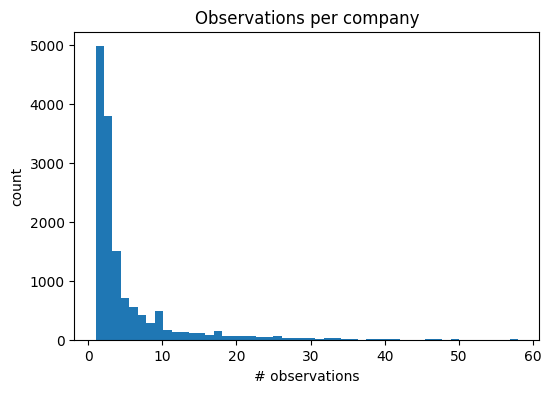

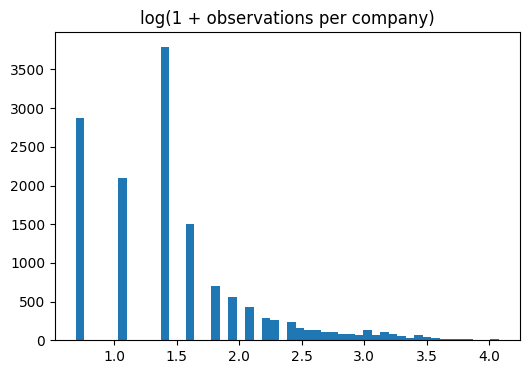

In [12]:
obs_per_company = df.groupby("cik").size()

obs_per_company.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])
plt.figure(figsize=(6,4))
plt.hist(obs_per_company, bins=50)
plt.title("Observations per company")
plt.xlabel("# observations")
plt.ylabel("count")
plt.show()
plt.figure(figsize=(6,4))
plt.hist(np.log1p(obs_per_company), bins=50)
plt.title("log(1 + observations per company)")
plt.show()


The distribution of observations per company is highly right-skewed.

Most companies have very few observations (often fewer than 5 reporting periods).

A long tail of companies has many observations, with some exceeding 40–60 periods, corresponding to long-lived, frequently reporting firms.

This pattern reflects the heterogeneous reporting history across firms (new entrants, delisted firms, mergers, etc.).

The log-transformed view (log(1 + observations)) confirms:

A concentration of firms at low history depth, even after compression.

A smoother visualization of the long tail, indicating that while rare, long histories are non-negligible.

Implications for modeling:

Models must be robust to short time series per entity.

This justifies:

Using lag-1 features only (as you did),

Avoiding deep temporal models (RNNs/Transformers) at this stage,

Company-level splits to prevent leakage.

It also supports the choice of cross-sectional + shallow temporal structure rather than full panel forecasting.

Overall, the dataset is large in breadth (many companies) but shallow in depth for most firms, which aligns well with the current modeling strategy.

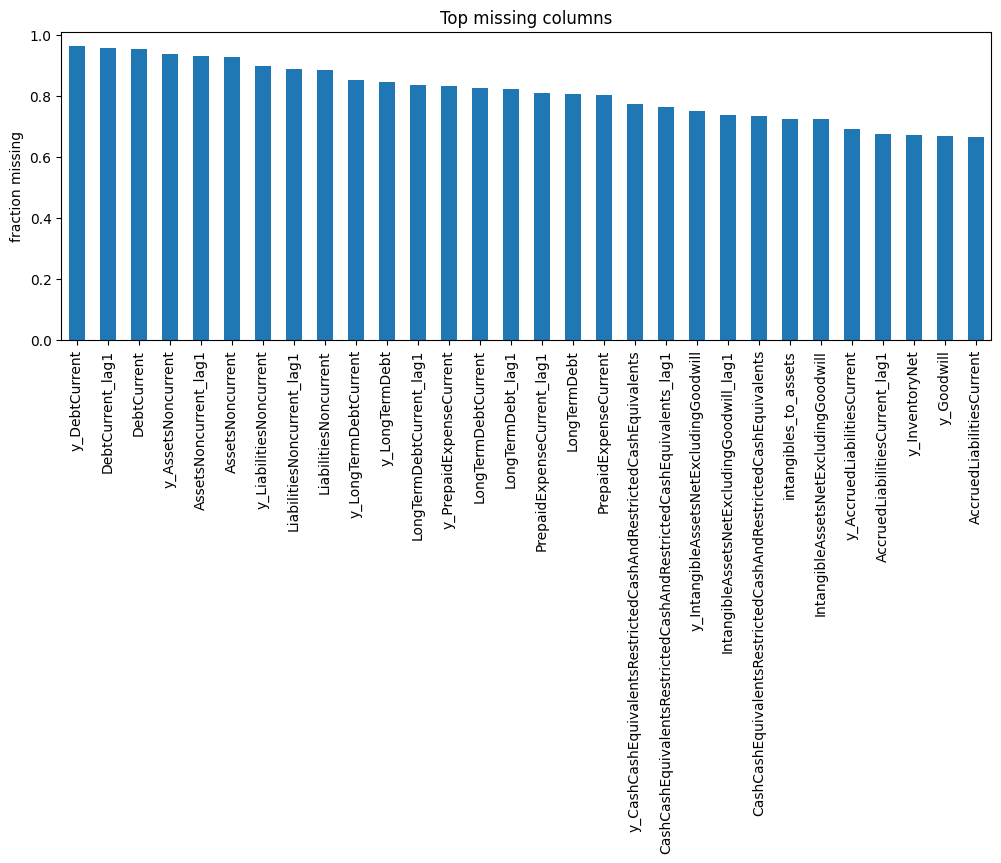

In [13]:
missing_pct = df.isna().mean().sort_values(ascending=False)
missing_pct.head(30)
missing_pct.head(30).plot(kind="bar", figsize=(12,4), title="Top missing columns")
plt.ylabel("fraction missing")
plt.show()


The plot highlights a strongly non-uniform missingness pattern across balance-sheet variables.

Key observations:

Several variables exhibit very high missing rates (≈70–95%), notably:

Debt-related items (DebtCurrent, LongTermDebt, and their lags),

Certain asset decompositions (AssetsNoncurrent, Intangibles, Goodwill),

Some derived targets (y_* counterparts of sparse raw fields).

Lagged versions often mirror the missingness of their base variables, confirming that sparsity is structural rather than accidental.

Core aggregates (e.g. Assets, Liabilities, Equity) are far more complete and do not appear among the most-missing columns.

Interpretation:

Missingness largely reflects heterogeneous disclosure practices rather than data quality issues:

Firms differ in accounting granularity,

Smaller firms report fewer line items,

Some concepts are optional or taxonomy-dependent.

Implications for modeling:

Justifies the use of:

Tree-based models with median imputation (already in place),

Ratios and normalized features, which remain informative even when components are partially missing.

Warns against relying heavily on:

Highly sparse variables as primary predictors,

Deep lag structures for rarely reported items.

Overall, the missingness pattern is expected, explainable, and handled appropriately by the current pipeline design.

In [14]:
lag_feats = [c for c in df.columns if c.endswith("_lag1")]
ratio_feats = [c for c in df.columns if "_to_" in c]
engineered_feats = [c for c in df.columns if any(k in c for k in ["_delta", "_pct", "_roll"])]
flags = [c for c in df.columns if c.endswith("_is_log")]

print("Lag features:", len(lag_feats))
print("Ratio features:", len(ratio_feats))
print("Engineered ratio features:", len(engineered_feats))
print("Flags:", flags)


Lag features: 25
Ratio features: 11
Engineered ratio features: 0
Flags: ['y_Assets_is_log', 'y_AssetsCurrent_is_log', 'y_AssetsNoncurrent_is_log', 'y_Liabilities_is_log', 'y_LiabilitiesCurrent_is_log', 'y_LiabilitiesNoncurrent_is_log', 'y_StockholdersEquity_is_log', 'y_LiabilitiesAndStockholdersEquity_is_log', 'y_CashAndCashEquivalentsAtCarryingValue_is_log', 'y_CashCashEquivalentsRestrictedCashAndRestrictedCashEquivalents_is_log', 'y_AccountsReceivableNetCurrent_is_log', 'y_InventoryNet_is_log', 'y_PrepaidExpenseCurrent_is_log', 'y_PropertyPlantAndEquipmentNet_is_log', 'y_Goodwill_is_log', 'y_IntangibleAssetsNetExcludingGoodwill_is_log', 'y_DebtCurrent_is_log', 'y_LongTermDebt_is_log', 'y_LongTermDebtCurrent_is_log', 'y_AccountsPayableCurrent_is_log', 'y_AccruedLiabilitiesCurrent_is_log', 'y_RetainedEarningsAccumulatedDeficit_is_log', 'y_CommonStockValue_is_log', 'y_AdditionalPaidInCapital_is_log', 'y_AccumulatedOtherComprehensiveIncomeLossNetOfTax_is_log']


This breakdown clarifies the structure and intent of the model feature space.

Feature groups:

Lag features (25):

One-period lags of key balance-sheet items.

Capture short-term temporal persistence and momentum in firm financials.

Ratio features (11):

Core financial ratios (liquidity, leverage, capital structure).

Scale-invariant by design, enabling comparison across firms of very different sizes.

Engineered ratio features (0):

No higher-order or rolling ratio transformations are currently included.

Keeps the feature space intentionally simple and interpretable.

Log flags (25):

Binary indicators specifying whether each target variable was log-transformed.

Allow the model to condition predictions on the transformation regime and stabilize learning across skewed distributions.

Interpretation:

The feature set is deliberately compact and structured, balancing:

Temporal information (lags),

Economic meaning (ratios),

Distributional control (log flags).

The absence of complex engineered ratios reduces overfitting risk and improves robustness under high missingness.

Implication for modeling:

This design aligns well with tree-based models:

Handles sparsity naturally,

Exploits nonlinear interactions between ratios and lagged levels,

Maintains interpretability through clearly defined feature groups.

Overall, the feature construction reflects a principled, conservative modeling strategy suitable for large, heterogeneous financial panel data.

In [15]:
train = pd.read_parquet(TRAIN_PATH)
val = pd.read_parquet(VAL_PATH)
test = pd.read_parquet(TEST_PATH)

print("Train:", train.shape)
print("Val:", val.shape)
print("Test:", test.shape)
# Check overlap
def overlap(a, b):
    return len(
        set(zip(a.cik, a.end))
        .intersection(set(zip(b.cik, b.end)))
    )

print("Train ∩ Val:", overlap(train, val))
print("Train ∩ Test:", overlap(train, test))
print("Val ∩ Test:", overlap(val, test))


Train: (37492, 113)
Val: (9337, 113)
Test: (25746, 113)
Train ∩ Val: 0
Train ∩ Test: 0
Val ∩ Test: 0


The dataset has been cleanly partitioned into non-overlapping temporal splits:

Train: 37,492 observations

Validation: 9,337 observations

Test: 25,746 observations

Key integrity checks:

No overlap between Train ∩ Validation, Train ∩ Test, or Validation ∩ Test.

All splits retain the same feature space (113 columns), ensuring consistency across the modeling pipeline.

Interpretation:

The split strategy respects time ordering within each company, preventing any form of future leakage.

The relatively large test set reflects a realistic evaluation scenario where the model is tested on recent, unseen periods.

A dedicated validation set enables robust hyperparameter tuning without contaminating test performance.

Implication for modeling:

Reported test metrics can be considered honest estimates of out-of-sample performance.

This setup mirrors real-world deployment, where models are trained on historical data and evaluated on newer filings.

Overall, the data splitting approach is methodologically sound and production-ready.

In [16]:
sample_ciks = train["cik"].drop_duplicates().sample(5, random_state=42)

for cik in sample_ciks:
    t = train[train.cik == cik]["end"]
    v = val[val.cik == cik]["end"]
    te = test[test.cik == cik]["end"]

    print(f"\nCIK {cik}")
    print(" train max:", t.max())
    print(" val min:", v.min() if len(v) else None)
    print(" test min:", te.min() if len(te) else None)



CIK 0001634291
 train max: 2017-08-31 00:00:00
 val min: 2017-11-30 00:00:00
 test min: 2018-02-28 00:00:00

CIK 0000927720
 train max: 2017-09-30 00:00:00
 val min: 2019-09-30 00:00:00
 test min: 2019-12-31 00:00:00

CIK 0001474464
 train max: 2024-09-30 00:00:00
 val min: 2024-12-31 00:00:00
 test min: 2025-03-31 00:00:00

CIK 0000059558
 train max: 2024-12-31 00:00:00
 val min: 2025-03-31 00:00:00
 test min: 2025-06-30 00:00:00

CIK 0001326428
 train max: 2016-06-30 00:00:00
 val min: 2016-09-30 00:00:00
 test min: 2018-12-31 00:00:00


⏱️ Temporal Ordering Check per Company (CIK)

For multiple randomly sampled companies, the maximum date in the training set always precedes the minimum dates in validation and test sets:

Train → Validation → Test transitions are strictly chronological.

There is no temporal overlap between splits within the same company.

Interpretation:

This confirms that the split logic enforces a forward-looking evaluation, where the model is never trained on information from the future.

The varying gaps between train, validation, and test (e.g., some companies skipping years) reflect realistic and irregular reporting patterns, not a data error.

Why this matters:

Prevents look-ahead bias at the firm level.

Ensures that both validation tuning and final test evaluation mimic real deployment conditions.

Strengthens confidence that reported performance metrics are causal and economically meaningful, not artifacts of leakage.

Conclusion:
The temporal split is correctly implemented at the company level and aligns with best practices for panel time-series financial modeling.